Topics covered: Activation Functions (Sigmoid, Tanh, ReLU, Leaky ReLU, Softmax), Loss Functions (Mean Squared Error, Binary Cross-Entropy, Categorical Cross-Entropy), Optimizers (Gradient Descent, Stochastic Gradient Descent, Adam), Vanishing Gradient Problem, Batch Size / Epochs / Learning Rate, ANN Implementation using TensorFlow/Keras https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification

Import libraries

In [1]:


import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Load the dataset

In [2]:
df = pd.read_csv("train.csv")

df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


Check the data

In [3]:
print(df.shape)

df.info()

print(df.isnull().sum())

(2000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 1

Separate X and y

In [4]:
X = df.drop("price_range", axis=1)

y = df["price_range"]

Train-test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Scale the data

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Build the ANN

In [7]:
model = Sequential()

model.add(Dense(64, activation="relu", input_shape=(X_train.shape[1],)))

model.add(Dense(32, activation="relu"))

model.add(Dense(4, activation="softmax"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile the model

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Train the ANN

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3156 - loss: 1.3772 - val_accuracy: 0.3406 - val_loss: 1.3025
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4852 - loss: 1.1886 - val_accuracy: 0.5219 - val_loss: 1.1500
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6242 - loss: 0.9974 - val_accuracy: 0.5875 - val_loss: 0.9570
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7148 - loss: 0.7954 - val_accuracy: 0.6781 - val_loss: 0.7723
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7789 - loss: 0.6326 - val_accuracy: 0.7656 - val_loss: 0.6294
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8422 - loss: 0.5121 - val_accuracy: 0.7906 - val_loss: 0.5354
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8750 - loss: 0.4249 - val_accuracy: 0.8531 - val_loss: 0.4504
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9023 - loss: 0.3560 - val_accuracy: 0.8813 - val_loss:

Evaluate

In [10]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9050 - loss: 0.2025  
Test Loss: 0.20254352688789368
Test Accuracy: 0.9049999713897705


Plot training and validation loss

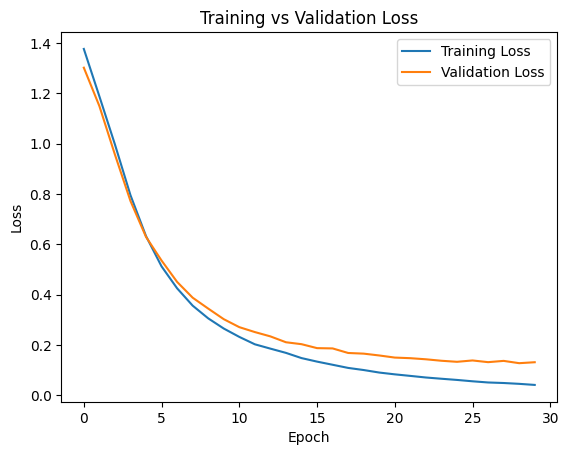

In [11]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

Make predictions

In [12]:
predictions = model.predict(X_test)

print(predictions[0])

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
[9.9792665e-01 2.0732877e-03 9.2850736e-12 1.4643675e-23]
